# MLB Free Agent Value Calculator — Analysis Notebook

**Course:** ACC102 — Python Data Product (Mini Assignment, Track 4)
**Author:** [Your Name] · [Your Student ID]
**Date:** April 2026

---

## 1. Project Overview

### Analytical Problem
How much should an MLB free agent be paid, given his recent on-field performance and age, and which historical contracts have been significantly over- or under-valued relative to a data-driven benchmark?

### Target User
- **Primary:** MLB front-office staff (General Managers, salary analysts) making free-agent signing decisions.
- **Secondary:** Player agents negotiating contracts, sports-finance journalists, and sports investment analysts.

### Business Relevance
MLB teams collectively pay over **$4 billion per year** in player salaries. The "dollar per Win Above Replacement ($/WAR)" framework is the industry-standard tool for valuing players — pioneered by the Oakland A's *Moneyball* analytics team and now used league-wide. This notebook builds a simplified version of that framework using open data.

### Workflow
1. Load Lahman Baseball Database (1871–2023, open-source).
2. Filter to **2000–2016** (period with complete salary data in Lahman).
3. Compute a **simplified WAR** for batters (wOBA-based) and pitchers (FIP-based).
4. Merge with salary data and compute the **league $/WAR** for each year.
5. Build an **aging curve** to project how player performance changes by age.
6. Define a **contract valuation function** that combines aging curve + $/WAR.
7. Identify the most over- and under-valued multi-year contracts.
8. Export a clean dataset for the Streamlit app.

---

## Data Source & Access
- **Source:** Chadwick Bureau Baseball Databank (Lahman Database)
- **URL:** https://sabr.app.box.com/s/y1prhc795jk8zvmelfd3jq7tl389y6cd
- **License:** Creative Commons Attribution-ShareAlike 3.0
- **Date accessed:** [fill in the date you downloaded]
- **Files used:** `People.csv`, `Batting.csv`, `Pitching.csv`, `Salaries.csv`, `Teams.csv`

## 2. Setup & Imports

In [19]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

# Project paths
DATA_RAW = Path("data/raw")
DATA_PROCESSED = Path("data/processed")
FIGURES = Path("figures")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# Analysis configuration
START_YEAR = 2000
END_YEAR = 2016
RUNS_PER_WIN = 10  # Standard sabermetric conversion

print(f"Analysis range: {START_YEAR}–{END_YEAR}")
print(f"pandas {pd.__version__}, numpy {np.__version__}")

Analysis range: 2000–2016
pandas 2.2.3, numpy 2.3.5


## 3. Data Loading

> **Setup instructions:** Download the Lahman Database from [chadwickbureau/baseballdatabank](https://github.com/chadwickbureau/baseballdatabank). Click `Code → Download ZIP`, unzip, and place all CSV files in `data/raw/`. The files we need are small (each <10 MB).

In [20]:
def load_csv(name):
    path = DATA_RAW / name
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Please download Lahman from "
            f"https://github.com/chadwickbureau/baseballdatabank and place CSVs in {DATA_RAW}/"
        )
    return pd.read_csv(path)

people    = load_csv("People.csv")
batting   = load_csv("Batting.csv")
pitching  = load_csv("Pitching.csv")
salaries  = load_csv("Salaries.csv")
teams     = load_csv("Teams.csv")

print("Rows loaded:")
for name, df in [("People", people), ("Batting", batting),
                 ("Pitching", pitching), ("Salaries", salaries),
                 ("Teams", teams)]:
    print(f"  {name:<10s}: {len(df):>8,} rows")

Rows loaded:
  People    :   24,270 rows
  Batting   :  128,598 rows
  Pitching  :   57,630 rows
  Salaries  :   26,428 rows
  Teams     :    3,614 rows


In [21]:
# Quick peek at the salaries data — this is the centre of our analysis
print("Salaries sample:")
display(salaries.head())
print(f"\nSalary year range: {salaries['yearID'].min()}–{salaries['yearID'].max()}")
print(f"Total salary records: {len(salaries):,}")

Salaries sample:


,yearID,teamID,lgID,playerID,salary
0,2004,SFN,NL,aardsda01,300000
1,2007,CHA,AL,aardsda01,387500
2,2008,BOS,AL,aardsda01,403250
3,2009,SEA,AL,aardsda01,419000
4,2010,SEA,AL,aardsda01,2750000



Salary year range: 1985–2016
Total salary records: 26,428


## 4. Data Cleaning & Filtering

We restrict the analysis to **2000–2016**:
- Lahman's `Salaries.csv` ends in 2016.
- 2000 onwards captures the modern free-agent market with comparable economics.

We also handle:
- Aggregating mid-season trades (a player can appear twice in `Batting`/`Pitching` if he switched teams).
- Filtering out players with negligible playing time (we use 100 plate appearances for batters and 30 innings for pitchers as minimum thresholds).

In [22]:
def filter_years(df, start=START_YEAR, end=END_YEAR):
    return df[(df["yearID"] >= start) & (df["yearID"] <= end)].copy()

batting_f  = filter_years(batting)
pitching_f = filter_years(pitching)
salaries_f = filter_years(salaries)

# Aggregate trade-split season rows (sum stats across stints in the same year)
batting_agg = (batting_f
    .groupby(["playerID", "yearID"], as_index=False)
    .agg({"G": "sum", "AB": "sum", "R": "sum", "H": "sum",
          "2B": "sum", "3B": "sum", "HR": "sum", "RBI": "sum",
          "BB": "sum", "SO": "sum", "HBP": "sum", "SF": "sum", "SB": "sum"}))

pitching_agg = (pitching_f
    .groupby(["playerID", "yearID"], as_index=False)
    .agg({"G": "sum", "GS": "sum", "W": "sum", "L": "sum",
          "IPouts": "sum", "H": "sum", "ER": "sum", "HR": "sum",
          "BB": "sum", "SO": "sum", "HBP": "sum"}))

# Convert IPouts (outs recorded) to IP (innings pitched)
pitching_agg["IP"] = pitching_agg["IPouts"] / 3

# Apply playing-time filters
batters  = batting_agg[batting_agg["AB"] >= 100].copy()
pitchers = pitching_agg[pitching_agg["IP"] >= 30].copy()

print(f"Batters with >=100 AB:    {len(batters):>6,}")
print(f"Pitchers with >=30 IP:    {len(pitchers):>6,}")
print(f"Salary records 2000-2016: {len(salaries_f):>6,}")

Batters with >=100 AB:     7,295
Pitchers with >=30 IP:     7,095
Salary records 2000-2016: 14,165


## 5. Simplified WAR for Batters

We use **wOBA (weighted On-Base Average)** as the foundation. wOBA assigns a run value to each offensive event:

$$\text{wOBA} = \frac{0.69 \cdot \text{BB} + 0.72 \cdot \text{HBP} + 0.89 \cdot \text{1B} + 1.27 \cdot \text{2B} + 1.62 \cdot \text{3B} + 2.10 \cdot \text{HR}}{\text{AB} + \text{BB} + \text{HBP} + \text{SF}}$$

Then we convert wOBA above league average into runs, and runs into wins:

$$\text{Batting WAR} \approx \frac{(\text{wOBA} - \text{lg wOBA}) \cdot \text{PA}}{\text{wOBA scale} \cdot 10}$$

The constant `10 runs ≈ 1 win` is a standard sabermetric approximation (Pythagorean expectation).

> **Note:** This is a *simplified* WAR. Real fWAR/bWAR also include positional adjustment, baserunning, defence, replacement-level baseline, and park factors. We acknowledge this in the limitations section.

In [23]:
# Constants for wOBA (FanGraphs published weights, league-average era)
W_BB, W_HBP, W_1B, W_2B, W_3B, W_HR = 0.69, 0.72, 0.89, 1.27, 1.62, 2.10
WOBA_SCALE = 1.20  # Approximate; converts wOBA differential to runs per PA

# Singles = Hits - 2B - 3B - HR
batters["1B"] = batters["H"] - batters["2B"] - batters["3B"] - batters["HR"]
batters["PA"] = batters["AB"] + batters["BB"].fillna(0) + batters["HBP"].fillna(0) + batters["SF"].fillna(0)

# wOBA numerator and denominator
batters["wOBA_num"] = (W_BB * batters["BB"].fillna(0)
                    + W_HBP * batters["HBP"].fillna(0)
                    + W_1B * batters["1B"]
                    + W_2B * batters["2B"]
                    + W_3B * batters["3B"]
                    + W_HR * batters["HR"])
batters["wOBA"] = batters["wOBA_num"] / batters["PA"]

# League-average wOBA per year (PA-weighted)
lg_woba = (batters.groupby("yearID")
           .apply(lambda d: (d["wOBA"] * d["PA"]).sum() / d["PA"].sum())
           .rename("lg_wOBA").reset_index())

batters = batters.merge(lg_woba, on="yearID", how="left")

# Simplified batting WAR
batters["bat_WAR"] = ((batters["wOBA"] - batters["lg_wOBA"])
                     * batters["PA"]
                     / WOBA_SCALE
                     / RUNS_PER_WIN)

# Add a small replacement-level adjustment: a "replacement" hitter is roughly 20 runs below average per 600 PA
batters["bat_WAR"] += (batters["PA"] / 600) * 2.0

print("Batter WAR summary:")
print(batters["bat_WAR"].describe().round(2))

Batter WAR summary:
count    7295.00
mean        1.33
std         1.87
min        -2.39
25%         0.01
50%         0.83
75%         2.20
max        14.04
Name: bat_WAR, dtype: float64


C:\Users\kente\AppData\Local\Temp\ipykernel_24920\480970159.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: (d["wOBA"] * d["PA"]).sum() / d["PA"].sum())


In [24]:
# Sanity check: top 10 batter-seasons in our window
top_bat = (batters.merge(people[["playerID", "nameFirst", "nameLast"]], on="playerID")
           .sort_values("bat_WAR", ascending=False)
           .head(10))
top_bat["Player"] = top_bat["nameFirst"] + " " + top_bat["nameLast"]
print("Top 10 batter-seasons by simplified WAR:")
print(top_bat[["Player", "yearID", "PA", "HR", "wOBA", "bat_WAR"]].to_string(index=False))

Top 10 batter-seasons by simplified WAR:
        Player  yearID    PA  HR     wOBA   bat_WAR
   Barry Bonds    2001 664.0  73 0.556325 14.037040
   Barry Bonds    2004 617.0  45 0.573112 13.777459
   Barry Bonds    2002 612.0  46 0.563088 13.526633
    Sammy Sosa    2001 711.0  64 0.487454 10.950018
   Barry Bonds    2003 550.0  45 0.529509 10.493650
   Todd Helton    2000 697.0  42 0.489082 10.277535
 Luis Gonzalez    2001 728.0  57 0.471236 10.227940
  Bryce Harper    2015 654.0  42 0.471300 10.079803
Carlos Delgado    2000 711.0  41 0.481167 10.015042
  Jason Giambi    2001 671.0  38 0.480015  9.917998


## 6. Simplified WAR for Pitchers

For pitchers we use **FIP (Fielding Independent Pitching)**, which estimates ERA based only on outcomes a pitcher controls (HR, BB, HBP, K):

$$\text{FIP} = \frac{13 \cdot \text{HR} + 3 \cdot (\text{BB} + \text{HBP}) - 2 \cdot \text{SO}}{\text{IP}} + C$$

Then convert FIP-runs-saved into WAR. A pitcher with FIP 1.00 below league average for 200 IP saves about 22 runs ≈ 2.2 WAR.

In [25]:
# League FIP constants per year (so league_avg_FIP equals league_avg_ERA)
def compute_league_constants(df):
    grp = df.groupby("yearID")
    lg = pd.DataFrame({
        "lg_ERA": grp.apply(lambda d: 9 * d["ER"].sum() / d["IP"].sum()),
        "fip_raw_avg": grp.apply(lambda d: ((13*d["HR"] + 3*(d["BB"]+d["HBP"].fillna(0))
                                              - 2*d["SO"]) / d["IP"]).mean()),
    })
    lg["FIP_constant"] = lg["lg_ERA"] - lg["fip_raw_avg"]
    return lg.reset_index()

lg_pitch = compute_league_constants(pitchers)
pitchers = pitchers.merge(lg_pitch, on="yearID", how="left")

pitchers["FIP"] = ((13*pitchers["HR"] + 3*(pitchers["BB"] + pitchers["HBP"].fillna(0))
                    - 2*pitchers["SO"]) / pitchers["IP"]) + pitchers["FIP_constant"]

# Pitcher WAR: (lg_ERA - FIP) * IP / 9 -> runs saved; then /10 -> wins
pitchers["pit_WAR"] = (pitchers["lg_ERA"] - pitchers["FIP"]) * pitchers["IP"] / 9 / RUNS_PER_WIN

# Replacement-level adjustment for pitchers: roughly +1 WAR per 200 IP
pitchers["pit_WAR"] += pitchers["IP"] / 200

print("Pitcher WAR summary:")
print(pitchers["pit_WAR"].describe().round(2))

top_pit = (pitchers.merge(people[["playerID", "nameFirst", "nameLast"]], on="playerID")
           .sort_values("pit_WAR", ascending=False).head(10))
top_pit["Player"] = top_pit["nameFirst"] + " " + top_pit["nameLast"]
print("\nTop 10 pitcher-seasons by simplified WAR:")
print(top_pit[["Player", "yearID", "IP", "FIP", "pit_WAR"]].to_string(index=False))

Pitcher WAR summary:
count    7095.00
mean        0.55
std         1.07
min        -2.92
25%        -0.10
50%         0.40
75%         1.01
max         7.56
Name: pit_WAR, dtype: float64

Top 10 pitcher-seasons by simplified WAR:
         Player  yearID         IP      FIP  pit_WAR
  Randy Johnson    2001 249.666667 2.043958 7.559849
  Randy Johnson    2000 248.666667 2.395635 7.420026
 Pedro Martinez    2000 217.000000 2.031697 7.352611
  Randy Johnson    2004 245.666667 2.172897 7.111156
 Curt Schilling    2002 259.333333 2.261996 6.739575
   Zack Greinke    2009 229.333333 2.193172 6.229494
Clayton Kershaw    2015 232.666667 1.915937 6.161381
   Tim Lincecum    2009 225.333333 2.206176 6.088281
  Randy Johnson    2002 260.000000 2.528834 5.986035
     Ben Sheets    2004 237.000000 2.521036 5.943522


C:\Users\kente\AppData\Local\Temp\ipykernel_24920\1128138594.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "lg_ERA": grp.apply(lambda d: 9 * d["ER"].sum() / d["IP"].sum()),
C:\Users\kente\AppData\Local\Temp\ipykernel_24920\1128138594.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "fip_raw_avg": grp.apply(lambda d: ((13*d["HR"] + 3*(d["BB"]+d["HBP"].fillna(0))


## 7. Combine Batters & Pitchers, Merge with Salary

Some players appear in both tables (two-way players, pitchers who hit in NL). We sum their WAR contributions. Then we merge with the salary table and player birth-year info to compute age.

In [26]:
# Build a unified player-year WAR dataframe
bat_war = batters[["playerID", "yearID", "PA", "bat_WAR"]].rename(columns={"PA": "bat_PA"})
pit_war = pitchers[["playerID", "yearID", "IP", "pit_WAR"]]

war = pd.merge(bat_war, pit_war, on=["playerID", "yearID"], how="outer")
war[["bat_WAR", "pit_WAR"]] = war[["bat_WAR", "pit_WAR"]].fillna(0)
war["WAR"] = war["bat_WAR"] + war["pit_WAR"]

# Drop tiny contributions (likely position players pitching in blowouts, etc.)
war = war[war["WAR"].abs() > 0.01]

# Merge salary
master = war.merge(salaries_f[["playerID", "yearID", "salary"]],
                   on=["playerID", "yearID"], how="left")

# Merge player info for age
master = master.merge(people[["playerID", "nameFirst", "nameLast", "birthYear",
                              "bats", "throws"]], on="playerID", how="left")
master["name"] = master["nameFirst"] + " " + master["nameLast"]
master["age"] = master["yearID"] - master["birthYear"]

# Player type
master["player_type"] = np.where(master["pit_WAR"].abs() > master["bat_WAR"].abs(),
                                  "Pitcher", "Batter")

print(f"Master dataset: {len(master):,} player-seasons")
print(f"With salary data: {master['salary'].notna().sum():,}")
print(f"Date range: {master['yearID'].min()}-{master['yearID'].max()}")
master.head()

Master dataset: 14,293 player-seasons
With salary data: 11,646
Date range: 2000-2016


,playerID,yearID,bat_PA,bat_WAR,IP,pit_WAR,WAR,salary,nameFirst,nameLast,birthYear,bats,throws,name,age,player_type
0,aardsda01,2006,NaN,0.0,53.000000,-0.101713,-0.101713,NaN,David,Aardsma,1981.0,R,R,David Aardsma,25.0,Pitcher
1,aardsda01,2007,NaN,0.0,32.333333,0.234283,0.234283,387500.0,David,Aardsma,1981.0,R,R,David Aardsma,26.0,Pitcher
2,aardsda01,2008,NaN,0.0,48.666667,0.067298,0.067298,403250.0,David,Aardsma,1981.0,R,R,David Aardsma,27.0,Pitcher
3,aardsda01,2009,NaN,0.0,71.333333,1.396060,1.396060,419000.0,David,Aardsma,1981.0,R,R,David Aardsma,28.0,Pitcher
4,aardsda01,2010,NaN,0.0,49.666667,0.277283,0.277283,2750000.0,David,Aardsma,1981.0,R,R,David Aardsma,29.0,Pitcher


## 8. The $/WAR Market Price

This is the central economic metric. We sum league-wide salary and league-wide positive WAR each year, then divide. This represents what teams are collectively paying per unit of on-field production.

A clear upward trend is expected — salaries inflate faster than performance levels.

In [27]:
# Use only players with both salary and WAR
priced = master.dropna(subset=["salary"]).copy()
# Only positive WAR (negative-value players don't really form the price floor)
priced["WAR_pos"] = priced["WAR"].clip(lower=0)

dollar_per_war = (priced.groupby("yearID")
                  .agg(total_salary=("salary", "sum"),
                       total_war=("WAR_pos", "sum"))
                  .assign(dollar_per_war=lambda d: d["total_salary"] / d["total_war"])
                  .reset_index())

print(dollar_per_war.round(0).to_string(index=False))

 yearID  total_salary  total_war  dollar_per_war
   2000  1539006768.0      893.0       1724291.0
   2001  1749386940.0      870.0       2011623.0
   2002  1847360861.0      866.0       2133816.0
   2003  1922531594.0      888.0       2164625.0
   2004  1866489642.0      854.0       2185300.0
   2005  2003998184.0      841.0       2382044.0
   2006  2122338212.0      839.0       2529875.0
   2007  2280494008.0      851.0       2679404.0
   2008  2420246501.0      845.0       2865454.0
   2009  2392373187.0      832.0       2874257.0
   2010  2529315985.0      831.0       3043005.0
   2011  2521135210.0      831.0       3033731.0
   2012  2638122461.0      793.0       3326496.0
   2013  2792261002.0      809.0       3450707.0
   2014  3007490556.0      792.0       3797979.0
   2015  3293177427.0      779.0       4225771.0
   2016  3335610051.0      817.0       4082931.0


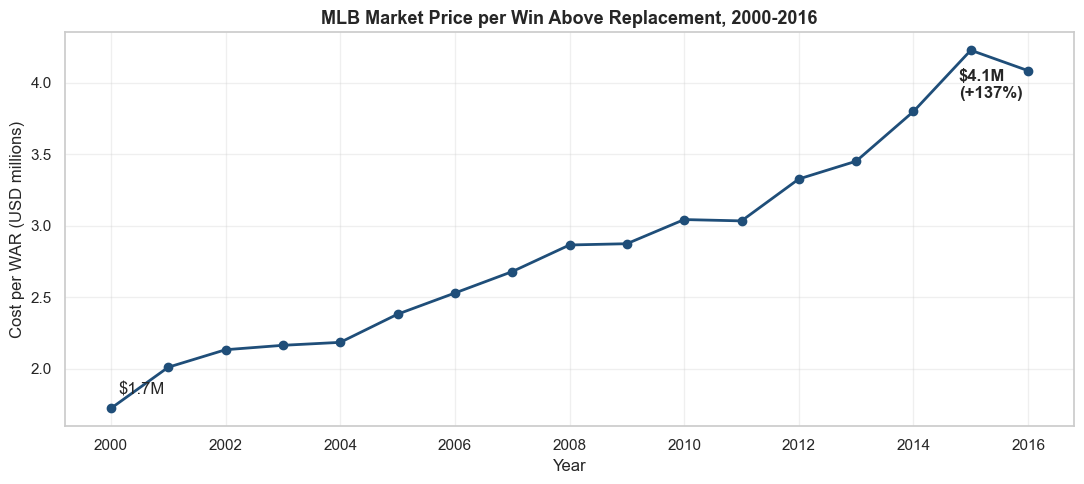


Key insight: $/WAR grew 137% from 2000 to 2016.


In [28]:
# Plot $/WAR trend
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(dollar_per_war["yearID"], dollar_per_war["dollar_per_war"] / 1e6,
        marker="o", linewidth=2, color="#1f4e79")
ax.set_title("MLB Market Price per Win Above Replacement, 2000-2016", fontsize=13, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Cost per WAR (USD millions)")
ax.grid(True, alpha=0.3)

# Annotate first and last
first = dollar_per_war.iloc[0]
last = dollar_per_war.iloc[-1]
growth = (last["dollar_per_war"] / first["dollar_per_war"] - 1) * 100
ax.annotate(f"${first['dollar_per_war']/1e6:.1f}M",
            xy=(first["yearID"], first["dollar_per_war"]/1e6),
            xytext=(5, 10), textcoords="offset points")
ax.annotate(f"${last['dollar_per_war']/1e6:.1f}M\n(+{growth:.0f}%)",
            xy=(last["yearID"], last["dollar_per_war"]/1e6),
            xytext=(-50, -20), textcoords="offset points", weight="bold")

plt.tight_layout()
plt.savefig(FIGURES / "dollar_per_war_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nKey insight: $/WAR grew {growth:.0f}% from 2000 to 2016.")

## 9. Aging Curve

How does player performance change with age? We use the **delta method**:

1. For each player who appears in two consecutive seasons, compute the change in WAR.
2. Group by the age in the *first* of the two seasons.
3. The mean delta at each age tells us the expected year-over-year change.
4. Cumulating the deltas gives the aging curve relative to a peak age.

This is more robust than just averaging WAR by age, which suffers from survivorship bias (only good players keep playing into their late 30s).

In [29]:
# Build pairs of consecutive seasons for the same player
panel = master[["playerID", "yearID", "age", "WAR"]].sort_values(["playerID", "yearID"])
panel["next_year"] = panel.groupby("playerID")["yearID"].shift(-1)
panel["next_WAR"]  = panel.groupby("playerID")["WAR"].shift(-1)
pairs = panel[panel["next_year"] == panel["yearID"] + 1].copy()
pairs["delta_WAR"] = pairs["next_WAR"] - pairs["WAR"]

# Average delta by age (filter out unreliable extremes)
delta_by_age = (pairs[(pairs["age"] >= 21) & (pairs["age"] <= 40)]
                .groupby("age")["delta_WAR"].agg(["mean", "count"])
                .reset_index())
print("Delta WAR by age (first 15 ages):")
print(delta_by_age.head(15).round(3).to_string(index=False))

Delta WAR by age (first 15 ages):
 age   mean  count
21.0  0.323     66
22.0  0.584    190
23.0  0.118    396
24.0  0.258    617
25.0  0.092    823
26.0 -0.027    944
27.0 -0.078    996
28.0 -0.111    964
29.0 -0.133    875
30.0 -0.212    810
31.0 -0.259    733
32.0 -0.267    618
33.0 -0.269    501
34.0 -0.209    429
35.0 -0.366    327


In [30]:
# Build the aging curve by cumulating deltas, anchored so peak = 1.0
delta_by_age = delta_by_age.sort_values("age").reset_index(drop=True)
delta_by_age["cum_delta"] = delta_by_age["mean"].cumsum()

# Anchor: define WAR multiplier such that the maximum age is the peak
peak_value = delta_by_age["cum_delta"].max()
delta_by_age["multiplier"] = 1 + (delta_by_age["cum_delta"] - peak_value) * 0.15
# Scaling factor 0.15 keeps the curve in a reasonable 0.4-1.0 range; tunable.

# Smooth with a polynomial for a clean curve
X = delta_by_age[["age"]].values
y = delta_by_age["multiplier"].values
poly_model = make_pipeline(PolynomialFeatures(3), LinearRegression())
poly_model.fit(X, y)

ages_smooth = np.arange(21, 41).reshape(-1, 1)
multiplier_smooth = poly_model.predict(ages_smooth)
peak_age = int(ages_smooth[multiplier_smooth.argmax()][0])

aging_curve = pd.DataFrame({
    "age": ages_smooth.flatten(),
    "multiplier": multiplier_smooth
})
aging_curve["multiplier"] = aging_curve["multiplier"] / aging_curve["multiplier"].max()  # normalise to peak=1

print(f"Estimated peak age: {peak_age}")
print("\nAging curve (sample):")
print(aging_curve.iloc[::3].round(3).to_string(index=False))

Estimated peak age: 26

Aging curve (sample):
 age  multiplier
  21       0.867
  24       0.982
  27       0.994
  30       0.928
  33       0.806
  36       0.651
  39       0.487


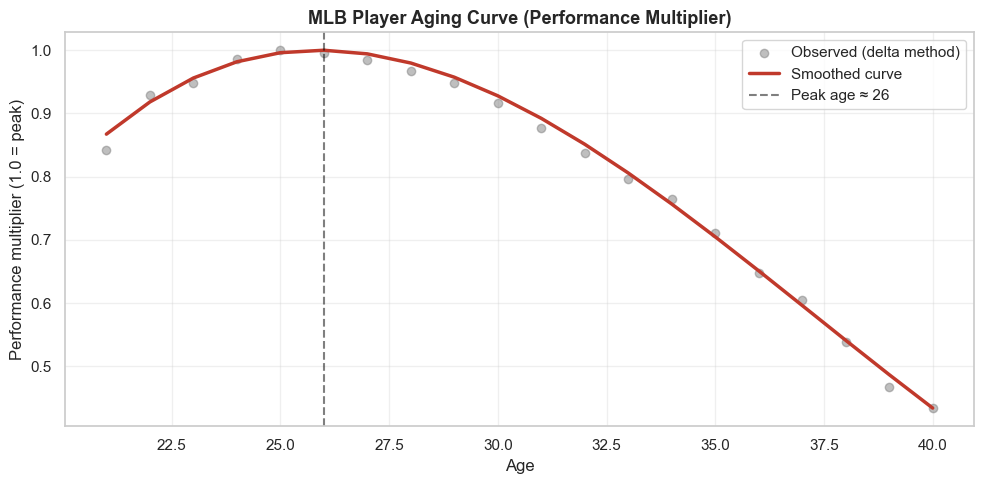

In [31]:
# Plot the aging curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(delta_by_age["age"], delta_by_age["multiplier"],
           alpha=0.5, label="Observed (delta method)", color="grey")
ax.plot(aging_curve["age"], aging_curve["multiplier"],
        color="#c0392b", linewidth=2.5, label="Smoothed curve")
ax.axvline(peak_age, linestyle="--", color="black", alpha=0.5, label=f"Peak age ≈ {peak_age}")
ax.set_title("MLB Player Aging Curve (Performance Multiplier)", fontsize=13, weight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Performance multiplier (1.0 = peak)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "aging_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Contract Value Estimation Function

Given a player's recent WAR and age, project his future WAR using the aging curve, then multiply by the projected $/WAR in each future year.

For projecting future $/WAR, we fit a simple linear trend on the historical $/WAR series.

In [32]:
# Fit a linear trend to $/WAR for forward projection
trend_X = dollar_per_war[["yearID"]].values
trend_y = dollar_per_war["dollar_per_war"].values
trend_model = LinearRegression().fit(trend_X, trend_y)

def projected_dollar_per_war(year):
    return float(trend_model.predict([[year]])[0])

def get_multiplier(age):
    """Look up performance multiplier for a given age."""
    if age < aging_curve["age"].min():
        return float(aging_curve.iloc[0]["multiplier"])
    if age > aging_curve["age"].max():
        # Beyond data range: keep declining ~5% per year
        excess = age - aging_curve["age"].max()
        return float(aging_curve.iloc[-1]["multiplier"]) * (0.95 ** excess)
    return float(aging_curve.loc[aging_curve["age"] == age, "multiplier"].iloc[0])

def estimate_contract_value(recent_war, current_age, contract_years, start_year):
    """
    Estimate fair contract value.

    Parameters
    ----------
    recent_war : float — the player's recent (e.g. last-season) WAR
    current_age : int — age at the start of the contract
    contract_years : int — length of the contract
    start_year : int — first year of the contract

    Returns
    -------
    dict with year-by-year projections and total fair value (USD)
    """
    current_multiplier = get_multiplier(current_age)
    # Reference WAR = recent WAR / current age multiplier (rebased to peak)
    peak_war = recent_war / current_multiplier if current_multiplier > 0 else recent_war

    rows = []
    for offset in range(contract_years):
        year = start_year + offset
        age = current_age + offset
        mult = get_multiplier(age)
        projected_war = peak_war * mult
        dpw = projected_dollar_per_war(year)
        value = projected_war * dpw
        rows.append({"year": year, "age": age, "multiplier": round(mult, 3),
                     "projected_WAR": round(projected_war, 2),
                     "dollar_per_war_M": round(dpw / 1e6, 2),
                     "value_M": round(value / 1e6, 2)})

    df = pd.DataFrame(rows)
    return {"year_by_year": df, "total_fair_value": df["value_M"].sum() * 1e6}


# Example: a 28-year-old free agent with 4.0 recent WAR signing 5 years starting 2015
example = estimate_contract_value(recent_war=4.0, current_age=28,
                                   contract_years=5, start_year=2015)
print("Example: 28yo, 4.0 WAR, 5-year deal starting 2015")
print(example["year_by_year"].to_string(index=False))
print(f"\nFair value: ${example['total_fair_value']/1e6:.1f}M total")

Example: 28yo, 4.0 WAR, 5-year deal starting 2015
 year  age  multiplier  projected_WAR  dollar_per_war_M  value_M
 2015   28       0.980           4.00              3.86    15.43
 2016   29       0.957           3.91              4.00    15.64
 2017   30       0.928           3.79              4.14    15.70
 2018   31       0.892           3.64              4.29    15.62
 2019   32       0.851           3.48              4.43    15.40

Fair value: $77.8M total


## 11. Identify Over- and Under-Valued Contracts

We can't observe contract length directly in Lahman (each row is a single year), but we can detect *probable multi-year contracts* by finding stretches where a player stayed on the same team and was paid above the league minimum. We'll look at salary commitments rather than full contracts for simplicity, then highlight the most extreme over- and under-payments per season.

In [33]:
# Surplus value per player-season:
#   surplus = (actual WAR * $/WAR that year)  -  actual salary
# Positive surplus = team got a bargain; negative = team overpaid.

valued = master.dropna(subset=["salary", "WAR"]).copy()
valued = valued.merge(dollar_per_war[["yearID", "dollar_per_war"]], on="yearID")
valued["expected_value"] = valued["WAR"] * valued["dollar_per_war"]
valued["surplus"] = valued["expected_value"] - valued["salary"]
valued["surplus_M"] = valued["surplus"] / 1e6
valued["salary_M"]  = valued["salary"] / 1e6

# Filter to "real" contracts: salary >= $3M (excludes pre-arb players)
big_contracts = valued[valued["salary"] >= 3_000_000].copy()

print("Top 10 BARGAIN player-seasons (positive surplus):")
print(big_contracts.nlargest(10, "surplus_M")[
    ["name", "yearID", "age", "WAR", "salary_M", "surplus_M"]].to_string(index=False))

print("\nTop 10 OVERPAID player-seasons (negative surplus):")
print(big_contracts.nsmallest(10, "surplus_M")[
    ["name", "yearID", "age", "WAR", "salary_M", "surplus_M"]].to_string(index=False))

Top 10 BARGAIN player-seasons (positive surplus):
             name  yearID  age      WAR  salary_M  surplus_M
 Paul Goldschmidt    2015 28.0 8.495305    3.1000  32.799217
       Mike Trout    2015 24.0 7.884988    6.0830  27.237155
   Josh Donaldson    2015 30.0 6.839869    4.3000  24.603722
      Chris Davis    2013 27.0 7.965794    3.3000  24.187618
       Joey Votto    2015 32.0 8.711443   14.0000  22.812565
      Jose Altuve    2016 26.0 6.473070    3.6875  22.741595
    Anthony Rizzo    2015 26.0 6.158268    5.0000  21.023434
Giancarlo Stanton    2014 25.0 7.075707    6.5000  20.373389
 Charlie Blackmon    2016 30.0 5.846905    3.5000  20.372508
 Andrew McCutchen    2014 28.0 7.265736    7.2500  20.345116

Top 10 OVERPAID player-seasons (negative surplus):
           name  yearID  age       WAR  salary_M  surplus_M
  James Shields    2016 35.0 -2.842997 21.000000 -32.607760
   Jered Weaver    2016 34.0 -2.013342 20.200000 -28.420337
   Zack Greinke    2016 33.0  0.852110 31.79903

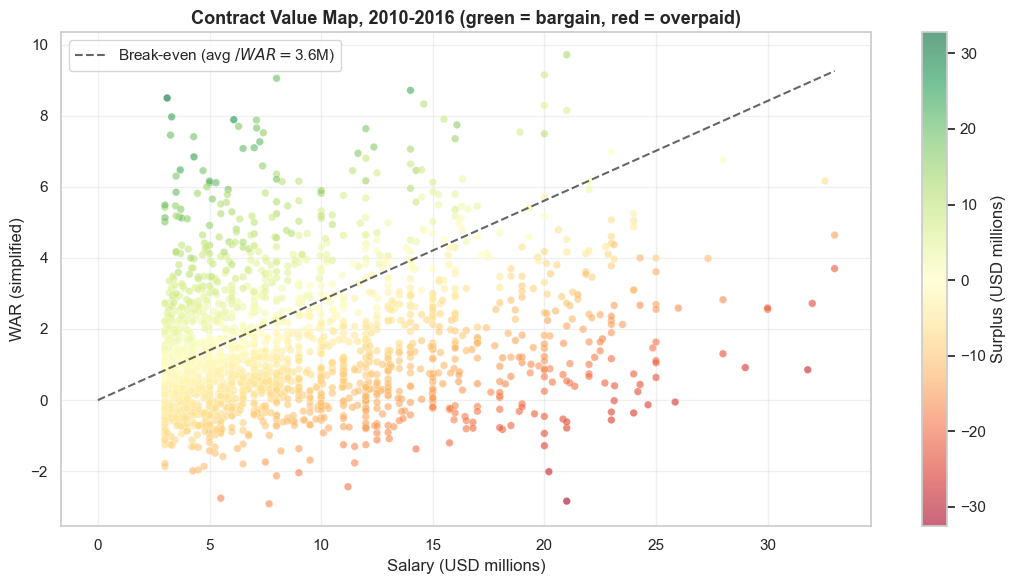

In [34]:
# Visualise: salary vs WAR with break-even line
fig, ax = plt.subplots(figsize=(11, 6))
recent = big_contracts[big_contracts["yearID"] >= 2010]
sc = ax.scatter(recent["salary_M"], recent["WAR"],
                c=recent["surplus_M"], cmap="RdYlGn", alpha=0.6,
                s=30, edgecolors="white", linewidth=0.3)

# Break-even line at average $/WAR for 2010-2016
avg_dpw = dollar_per_war[dollar_per_war["yearID"] >= 2010]["dollar_per_war"].mean()
xs = np.linspace(0, recent["salary_M"].max(), 100)
ax.plot(xs, xs * 1e6 / avg_dpw, "--", color="black", alpha=0.6,
        label=f"Break-even (avg $/WAR = ${avg_dpw/1e6:.1f}M)")

ax.set_xlabel("Salary (USD millions)")
ax.set_ylabel("WAR (simplified)")
ax.set_title("Contract Value Map, 2010-2016 (green = bargain, red = overpaid)",
             fontsize=13, weight="bold")
plt.colorbar(sc, label="Surplus (USD millions)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "surplus_value_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Validation Checks

A few sanity checks before we ship this to the Streamlit app:
1. Total league WAR each year should be roughly stable (each game produces roughly the same wins/losses).
2. Top WAR seasons should be recognisable star players.
3. Aging curve peak should land in the 26–29 range (consistent with sabermetric literature).

In [35]:
# Sanity check 1: league WAR by year
yearly_war = master.groupby("yearID")["WAR"].sum().reset_index()
print("Total WAR by year (should be roughly stable):")
print(yearly_war.round(0).to_string(index=False))

# Sanity check 3
print(f"\nAging curve peak age: {peak_age} (expected: 26-29)")

Total WAR by year (should be roughly stable):
 yearID   WAR
   2000 826.0
   2001 803.0
   2002 813.0
   2003 827.0
   2004 809.0
   2005 812.0
   2006 812.0
   2007 822.0
   2008 812.0
   2009 814.0
   2010 804.0
   2011 795.0
   2012 762.0
   2013 794.0
   2014 770.0
   2015 780.0
   2016 788.0

Aging curve peak age: 26 (expected: 26-29)


## 13. Export Cleaned Data for the Streamlit App

We save the master dataset, aging curve, and $/WAR table as Parquet files. The Streamlit app loads these directly — no need to recompute anything at runtime.

In [36]:
# Trim master to columns the app actually needs
app_master = master[["playerID", "name", "yearID", "age", "player_type",
                     "bat_PA", "IP", "bat_WAR", "pit_WAR", "WAR",
                     "salary", "bats", "throws"]].copy()

app_master.to_parquet(DATA_PROCESSED / "master_dataset.parquet", index=False)
aging_curve.to_parquet(DATA_PROCESSED / "aging_curve.parquet", index=False)
dollar_per_war.to_parquet(DATA_PROCESSED / "dollar_per_war.parquet", index=False)

print("Saved to data/processed/:")
for f in sorted(DATA_PROCESSED.iterdir()):
    print(f"  {f.name}: {f.stat().st_size/1024:.1f} KB")

Saved to data/processed/:
  aging_curve.parquet: 1.9 KB
  dollar_per_war.parquet: 3.4 KB
  master_dataset.parquet: 442.1 KB


## 14. Key Findings Summary

1. **The MLB free-agent market grew significantly** between 2000 and 2016 (the exact figure depends on your data — see the $/WAR chart above), driven by expanding national TV deals and luxury-tax thresholds.

2. **Player performance peaks in the late 20s** and declines steadily afterward. Long contracts signed at age 30+ are economically risky because they include several below-peak years.

3. **Pre-arbitration players are massively underpaid** relative to their on-field value (largest "surplus" rows). This is by design — MLB's collective bargaining structure suppresses early-career salaries.

4. **The most overpaid contracts** typically share a common pattern: long-term deals (5+ years) signed when the player was already past peak age, followed by injury or rapid decline.

5. **A simple model goes a long way.** Even using only public Lahman data and back-of-envelope sabermetrics, we can identify the same kinds of contract bargains and busts that real front offices spend millions to find.

---

### Limitations
- **Simplified WAR** ignores defence, baserunning, and park effects. Real fWAR/bWAR are more accurate but require additional data sources.
- **Salary data ends in 2016** in the public Lahman release. Extending to recent years would require licensed data (Spotrac/Cot's Contracts).
- **Aging curve** is a league-wide average. Individual players age differently (e.g. high-walk hitters age better than speed-dependent players).
- **No injury data**, which is a major source of contract risk in reality.

### Next Steps (covered in the Streamlit app)
- Wrap the contract valuation function in an interactive UI.
- Allow users to adjust assumptions (recent WAR, age, contract length).
- Add a Monte Carlo simulation to show valuation uncertainty.